<a href="https://colab.research.google.com/github/Oyuka-agi/Aaski/blob/main/Aarki_analyst_Oyun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, linregress

Quick summary

[1. EDA](#1.EDA)

[2. Trends of Call Status Overtime](#2.Trends)

[3. Drivers of Lead](#3.Drivers of Lead)

### 1. EDA

In [57]:
#read
df_raw = pd.read_excel(r"/content/Analyst_case_study_dataset_1_(1).xlsx")

In [ ]:
df_raw.columns

Index(['LeadCreated', 'FirstName', 'Email', 'VendorLeadID', 'CallStatus',
       'WidgetName', 'PublisherZoneName', 'PublisherCampaignName',
       'AddressScore', 'PhoneScore', 'AdvertiserCampaignName', 'State',
       'DebtLevel', 'IP Address', 'Partner', 'ReferralDomain',
       'MarketingCampaign', 'AdGroup', 'Keyword', 'SearchQuery', 'ReferralURL',
       'ReferralURL Parameters', 'LandingPageURL',
       'Landing Page URL Parameters'],
      dtype='object')

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3021 entries, 0 to 3020
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   LeadCreated                  3021 non-null   datetime64[ns]
 1   FirstName                    3021 non-null   object        
 2   Email                        3021 non-null   object        
 3   VendorLeadID                 3013 non-null   object        
 4   CallStatus                   881 non-null    object        
 5   WidgetName                   3021 non-null   object        
 6   PublisherZoneName            3021 non-null   object        
 7   PublisherCampaignName        3021 non-null   object        
 8   AddressScore                 1171 non-null   float64       
 9   PhoneScore                   1393 non-null   float64       
 10  AdvertiserCampaignName       3021 non-null   object        
 11  State                        3021 non-null 

In [100]:
duplicate_emails = df[df.duplicated('Email', keep=False)]
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     display(duplicate_emails.sort_values(by=['Email', 'LeadCreated']))

Assuming that the "Email" column is generated for the purpose of the case study. Ignoring duplicates.

In [75]:
# 1.1 Cleaning
df = df_raw.copy()
df["Month"] = df["LeadCreated"].dt.to_period('M')
df = df.drop(columns=['IP Address']) #dropping this column - as this is all Nan column
# df['Partner'] = df['Partner'].replace('google', 'Google')
# display(df['Partner'].unique())
df['CallStatus'] = df['CallStatus'].fillna('No Info')
#Cleaning WidgetName:
widget_split = df['WidgetName'].str.split('-', expand=True)
df['Form_Pages'] = widget_split[3]
df['Design_Style'] = widget_split[4]
#  302252, 300250 is same
df['WidgetStand'] = df['WidgetName'].str.replace('302252', '300250')
df['Lead_Friction_Type'] = df['Form_Pages'] + "_" + df['Design_Style'].fillna('Standard')

#good/bad quality
good_quality = ['Closed', 'EP Sent', 'EP Received', 'EP Confirmed']
bad_quality = ['Unable to contact - Bad Contact Information','Contacted - Invalid Profile','Contacted - Doesn\'t Qualify', 'No Info']
# Create a new binary column that is good qual or not
df['Is_Good'] = df['CallStatus'].apply(lambda x: 1 if x in good_quality else (0 if x in bad_quality else None))
# dropping uknown or NA
df_clean = df.dropna(subset=['Is_Good'])

In [65]:
df["CallStatus"].unique()

array([nan, 'Unable to contact - Bad Contact Information',
       "Contacted - Doesn't Qualify", 'Closed', 'EP Received',
       'EP Confirmed', 'Contacted - Invalid Profile', 'EP Sent'],
      dtype=object)

### 2.Trends

In [71]:

callstatus_monthly = df.groupby(['Month', 'CallStatus']).size().unstack(fill_value=0)
callstatus_proportions = callstatus_monthly.div(callstatus_monthly.sum(axis=1), axis=0)

In [67]:
callstatus_proportions

CallStatus,Closed,Contacted - Doesn't Qualify,Contacted - Invalid Profile,EP Confirmed,EP Received,EP Sent,Unable to contact - Bad Contact Information
Month,,,,,,,
2009-04,0.411765,0.000000,0.110294,0.139706,0.007353,0.022059,0.308824
2009-05,0.318966,0.008621,0.206897,0.172414,0.008621,0.008621,0.275862
2009-06,0.277533,0.308370,0.088106,0.083700,0.000000,0.017621,0.224670
2009-07,0.207547,0.452830,0.050314,0.094340,0.000000,0.006289,0.188679
2009-08,0.317829,0.263566,0.077519,0.155039,0.000000,0.007752,0.178295
2009-09,0.131579,0.307018,0.070175,0.324561,0.000000,0.052632,0.114035


<Figure size 1400x700 with 0 Axes>

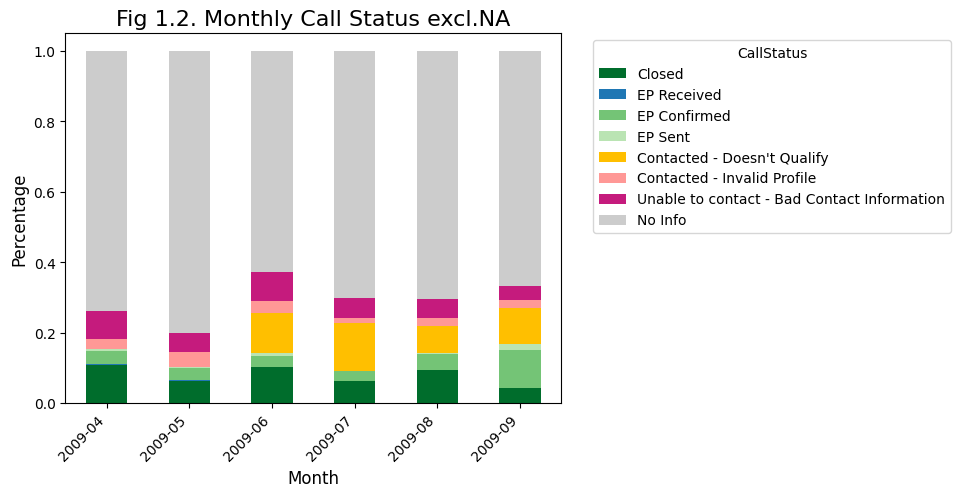

In [74]:
column_order = ['Closed', 'EP Received', 'EP Confirmed', 'EP Sent', "Contacted - Doesn't Qualify", 'Contacted - Invalid Profile', 'Unable to contact - Bad Contact Information', 'No Info']

#filter
orders = [col for col in column_order if col in callstatus_proportions.columns]

# Define a custom color palette
custom_colors = {
    'Closed': '#006d2c', # Darker green for Closed
    'EP Received': '#1f77b4', # Blue for EP Received
    'EP Confirmed': '#74c476', # Medium-light green
    'EP Sent': '#bae4b3', # Lighter green
    "Contacted - Doesn't Qualify": '#ffbf00', # Yellow reddish
    'Contacted - Invalid Profile': '#ff9896', # Light red
    'Unable to contact - Bad Contact Information': '#c51b7d', # Darker red
    'No Info': '#cccccc' # gray
}

#custom colors
colors_to_use = [custom_colors[col] for col in orders]

#reindex
callstatus_proportions_ordered = callstatus_proportions[orders]
#plot
plt.figure(figsize=(14, 7))
callstatus_proportions_ordered.plot(kind='bar', stacked=True, color=colors_to_use)

plt.title('Fig 1.2. Monthly Call Status excl.NA', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='CallStatus', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

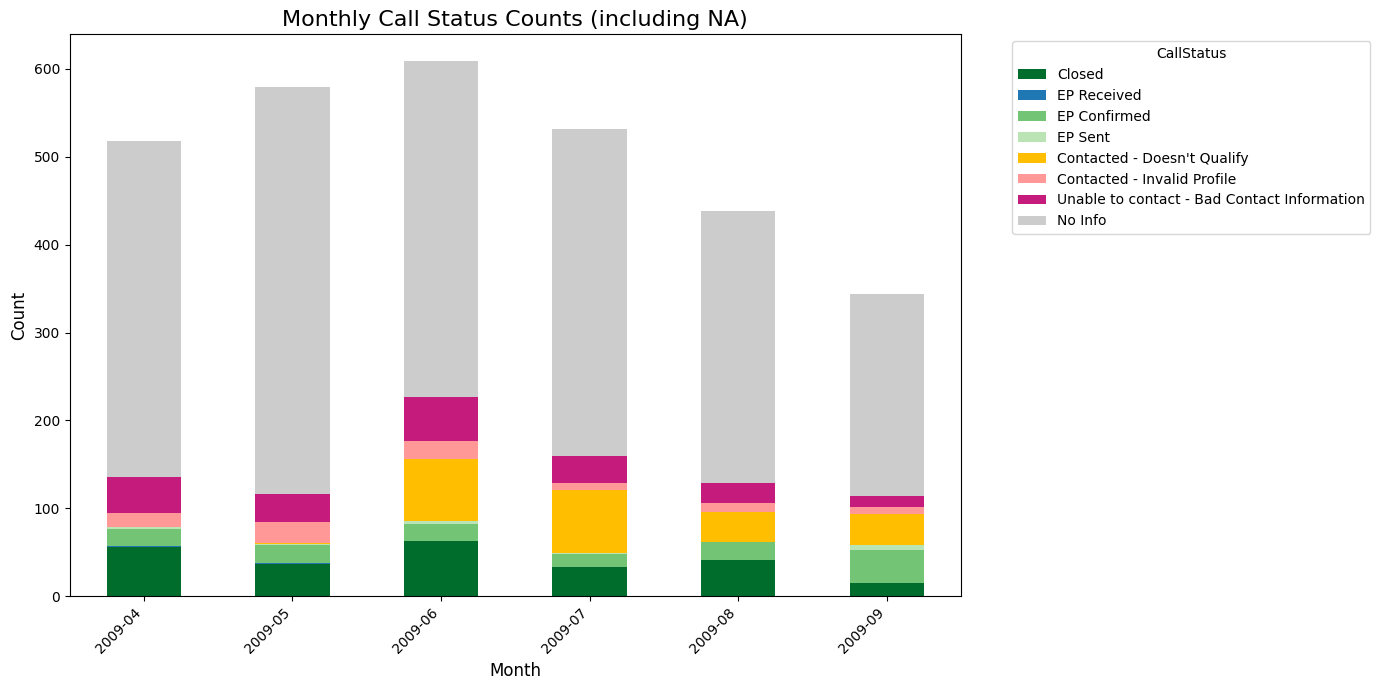

In [11]:
#pivot
callstatus_monthly = df.groupby(['Month', 'CallStatus']).size().unstack(fill_value=0)

#anothe order
column_order1 = ['Closed', 'EP Received', 'EP Confirmed', 'EP Sent', "Contacted - Doesn't Qualify", 'Contacted - Invalid Profile', 'Unable to contact - Bad Contact Information', 'No Info']

# Filter the column_order to include only columns present in callstatus_monthly
orders1 = [col for col in column_order1 if col in callstatus_monthly.columns] #use column_order for no NA

# Define a custom color palette
custom_colors1 = {
    'Closed': '#006d2c', # Darker green for Closed
    'EP Received': '#1f77b4', # Blue for EP Received
    'EP Confirmed': '#74c476', # Medium-light green
    'EP Sent': '#bae4b3', # Lighter green
    "Contacted - Doesn't Qualify": '#ffbf00', # Yellow reddish
    'Contacted - Invalid Profile': '#ff9896', # Light red
    'Unable to contact - Bad Contact Information': '#c51b7d', # Darker red
    'No Info': '#cccccc' # gray
}

#in queue
colors_to_use1 = [custom_colors1[col] for col in orders1]
#reindex
callstatus_monthly_ordered = callstatus_monthly[orders1]

#plot
plt.figure(figsize=(14, 7))
callstatus_monthly_ordered.plot(kind='bar', stacked=True, ax=plt.gca(), color=colors_to_use1)

plt.title('Monthly Call Status Counts (including NA)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='CallStatus', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
callstatus_monthly

CallStatus,Closed,Contacted - Doesn't Qualify,Contacted - Invalid Profile,EP Confirmed,EP Received,EP Sent,No Info,Unable to contact - Bad Contact Information
Month,,,,,,,,
2009-04,56,0,15,19,1,3,382,42
2009-05,37,1,24,20,1,1,464,32
2009-06,63,70,20,19,0,4,382,51
2009-07,33,72,8,15,0,1,373,30
2009-08,41,34,10,20,0,1,309,23
2009-09,15,35,8,37,0,6,230,13


In [76]:
# Create contingency table
cont_table = pd.crosstab(df_clean['Month'], df_clean['Is_Good'])
cont_table["Quality rate"] = (cont_table[1] / (cont_table[0] + cont_table[1]) )*100
cont_table.index = cont_table.index.to_timestamp()
print(cont_table)
#test
chi2, p, dof, expected = chi2_contingency(cont_table)

print(f"Chi-Square Statistic: {chi2:0.8f}")
print(f"P-value: {p:0.11f}")
print("The change in lead quality over time IS statistically significant.")


Is_Good       0   1  Quality rate
Month                            
2009-04-01  439  79     15.250965
2009-05-01  521  59     10.172414
2009-06-01  523  86     14.121511
2009-07-01  483  49      9.210526
2009-08-01  376  62     14.155251
2009-09-01  286  58     16.860465
Chi-Square Statistic: 29.53543706
P-value: 0.00102001858
The change in lead quality over time IS statistically significant.


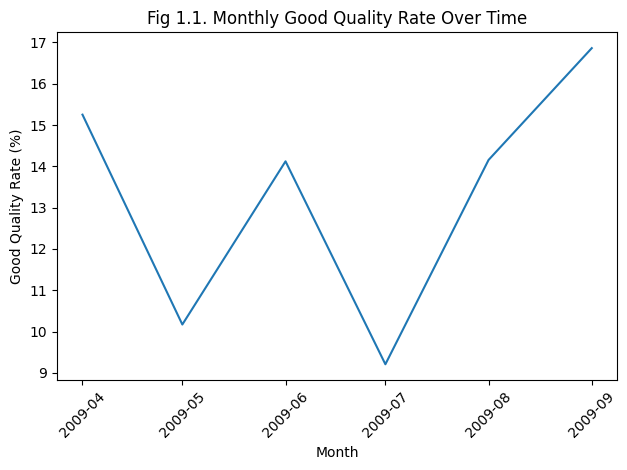

In [78]:
plt.plot(cont_table["Quality rate"])
plt.title('Fig 1.1. Monthly Good Quality Rate Over Time')
plt.xlabel('Month')
plt.ylabel('Good Quality Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#3. Drivers of Lead

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 881 entries, 2 to 3012
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   LeadCreated                  881 non-null    datetime64[ns]
 1   FirstName                    881 non-null    object        
 2   Email                        881 non-null    object        
 3   VendorLeadID                 873 non-null    object        
 4   CallStatus                   881 non-null    object        
 5   WidgetName                   881 non-null    object        
 6   PublisherZoneName            881 non-null    object        
 7   PublisherCampaignName        881 non-null    object        
 8   AddressScore                 354 non-null    float64       
 9   PhoneScore                   426 non-null    float64       
 10  AdvertiserCampaignName       881 non-null    object        
 11  State                        881 non-null    obje

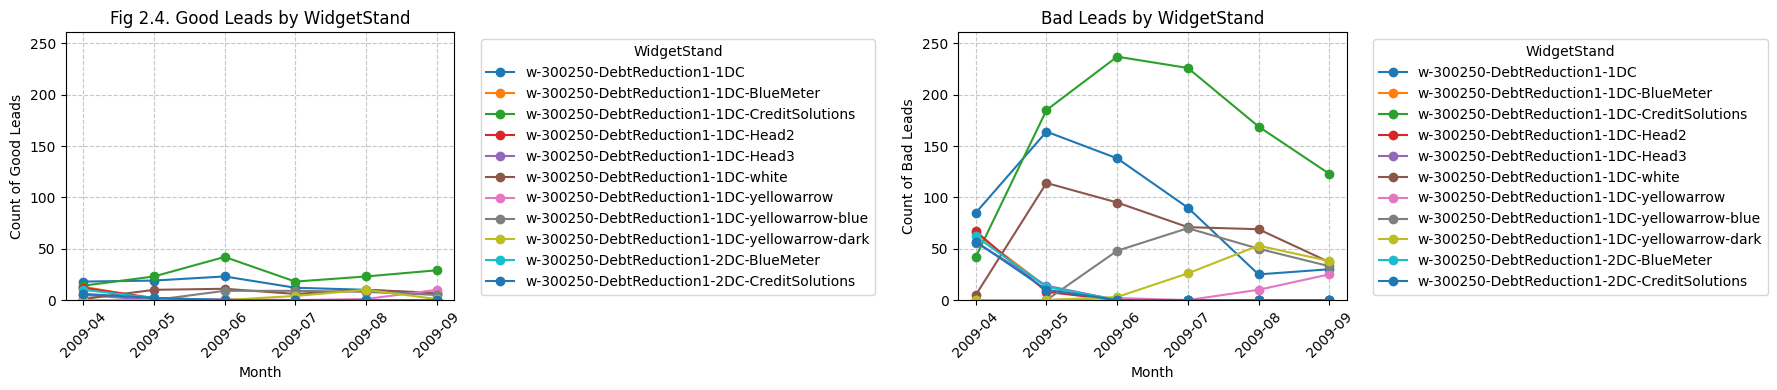

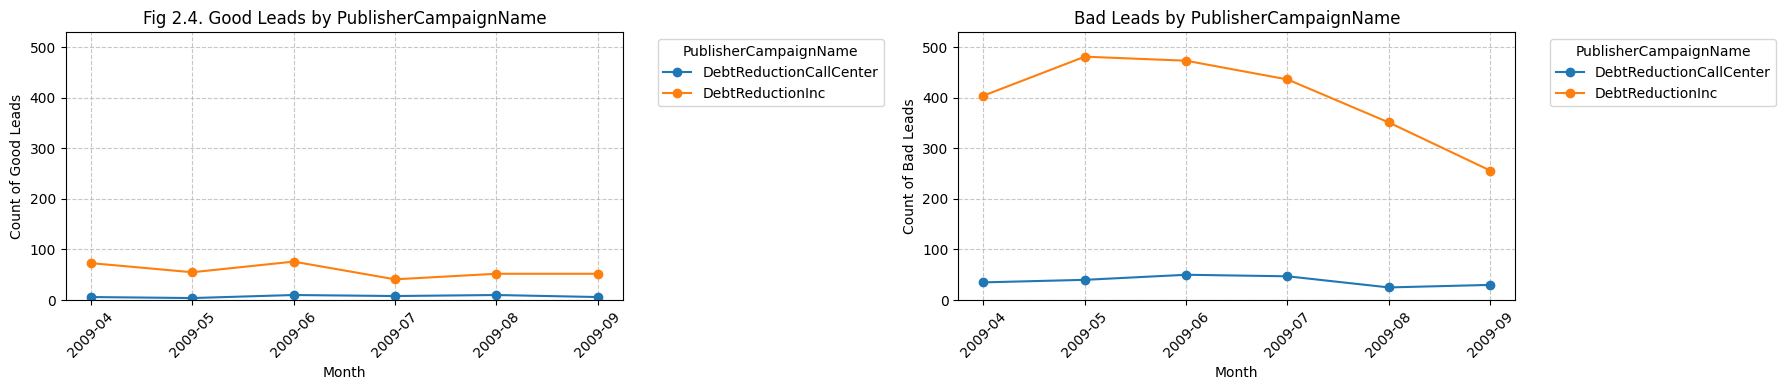

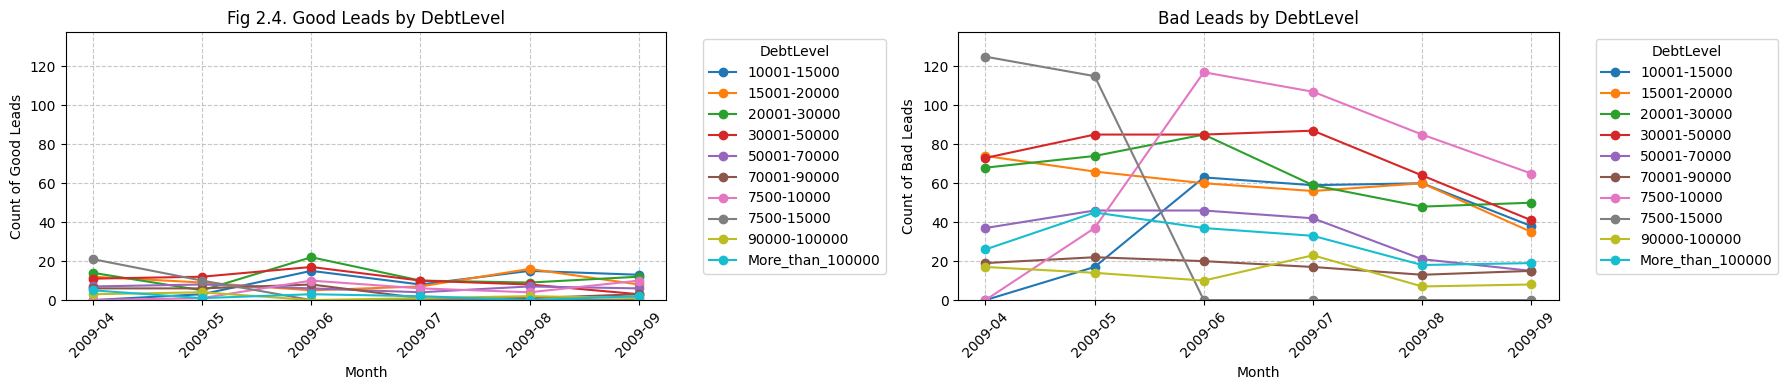

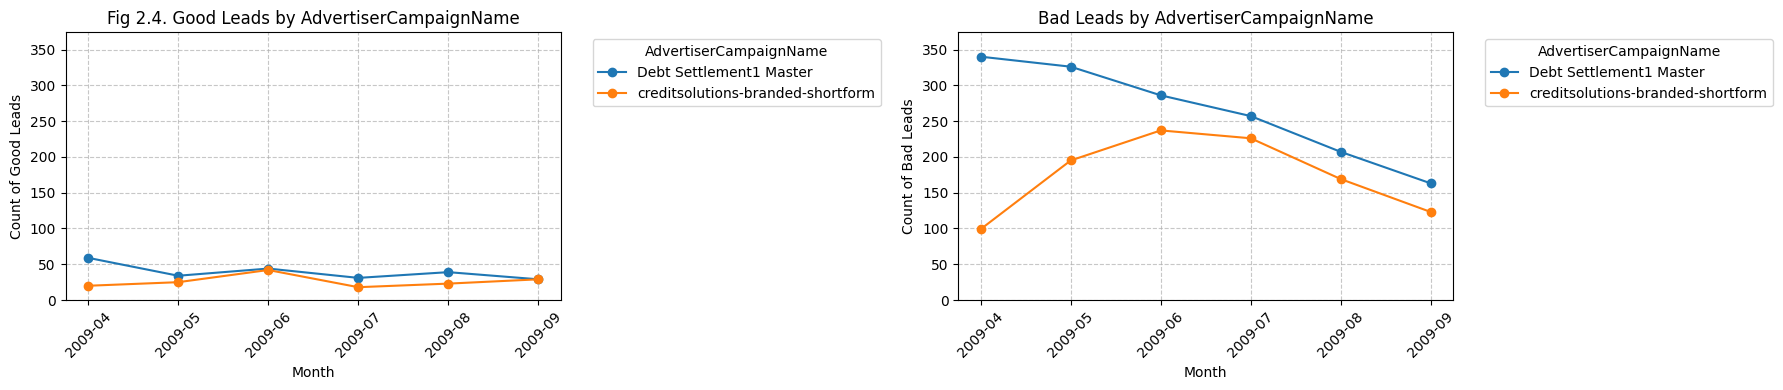

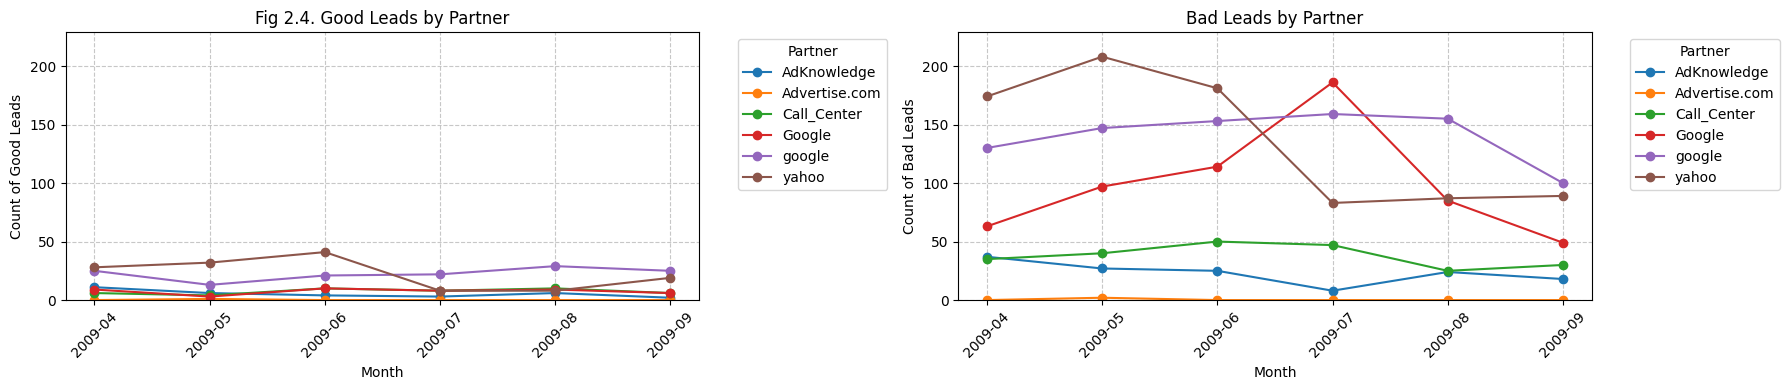

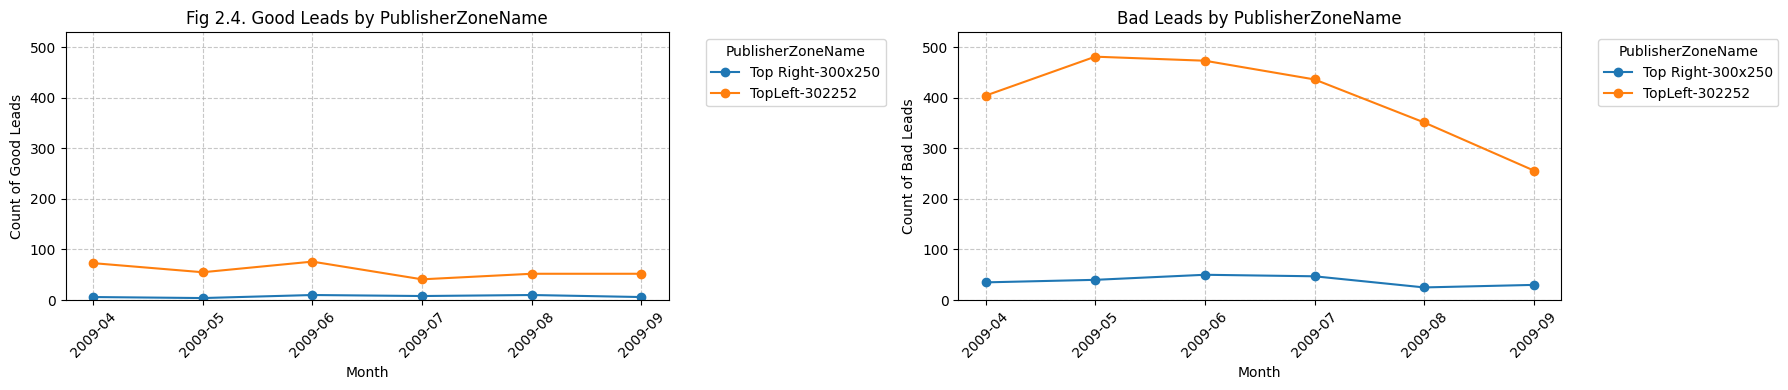

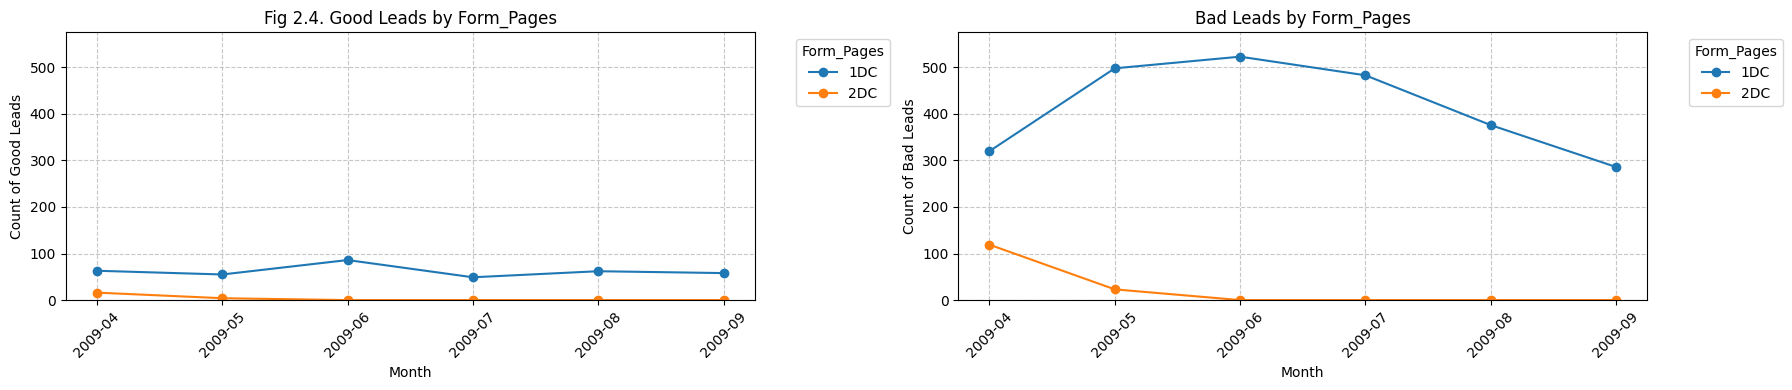

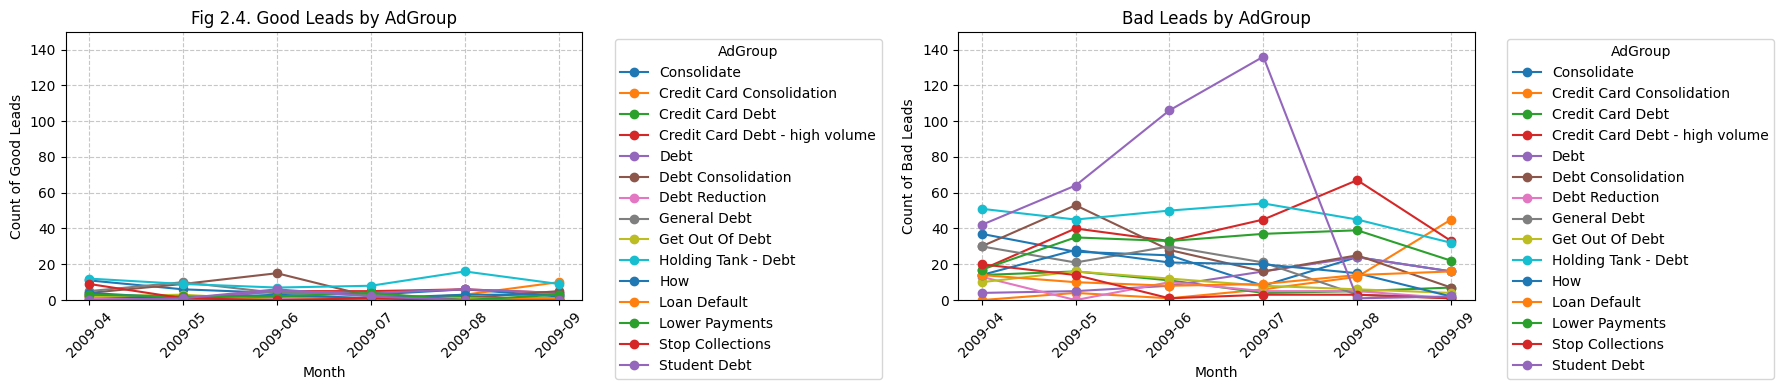

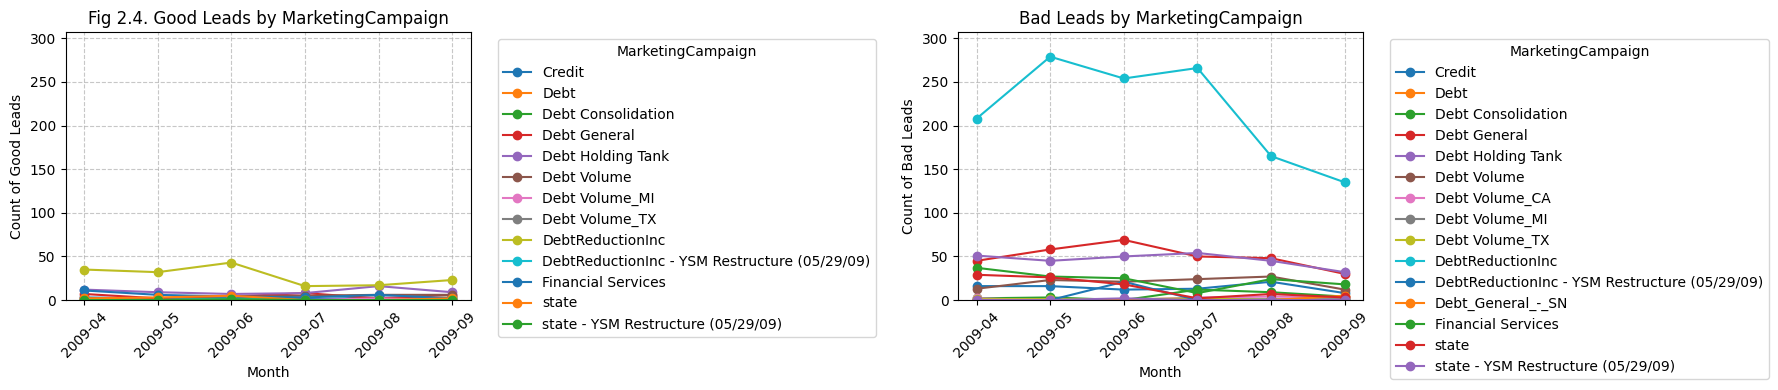

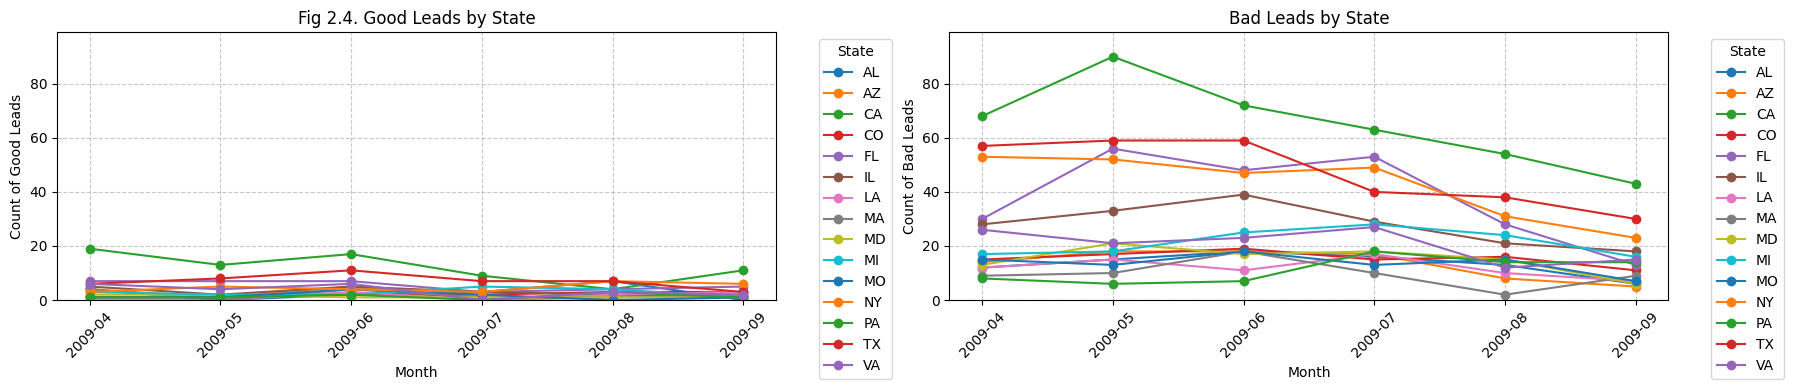

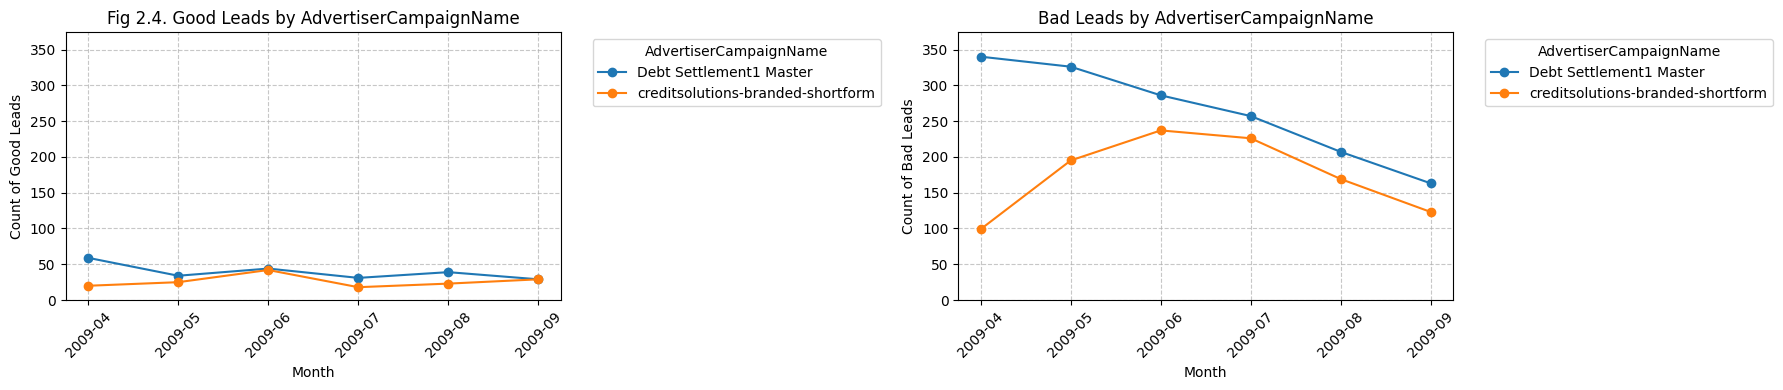

table
--------------------

Top & Bottom Performers for: WidgetStand
                                              Total Leads  Quality Rate
WidgetStand                                                            
w-300250-DebtReduction1-1DC-yellowarrow                49      0.244898
w-300250-DebtReduction1-1DC-Head2                      89      0.157303
w-300250-DebtReduction1-1DC-BlueMeter                  92      0.152174
w-300250-DebtReduction1-1DC                           620      0.141935
w-300250-DebtReduction1-2DC-BlueMeter                  87      0.137931
w-300250-DebtReduction1-1DC-yellowarrow-blue          232      0.133621
w-300250-DebtReduction1-1DC-CreditSolutions          1131      0.131742
w-300250-DebtReduction1-1DC-yellowarrow-dark          135      0.111111
w-300250-DebtReduction1-2DC-CreditSolutions            75      0.106667
w-300250-DebtReduction1-1DC-white                     436      0.103211
w-300250-DebtReduction1-1DC-Head3                      75      0.06

In [89]:
# Ensure Month is in a sortable format
df_clean['Month_Str'] = df_clean['Month'].astype(str)

categories = ['WidgetStand', 'PublisherCampaignName', 'DebtLevel', 'AdvertiserCampaignName', 'Partner', 'PublisherZoneName', "Form_Pages", 'AdGroup', "MarketingCampaign", "State", 'AdvertiserCampaignName']

# Overtime bad/good leads drivers
for dim in categories:
    # can filter first n numbers
    n = 15
    top_items = df_clean[dim].value_counts().nlargest(n).index
    df_plot = df_clean[df_clean[dim].isin(top_items)]

    # Prepare data for good leads (Is_Good == 1)
    good_leads_df = df_plot[df_plot['Is_Good'] == 1.0].groupby(['Month_Str', dim]).size().unstack(fill_value=0)
    # Prepare data for bad leads (Is_Good == 0)
    bad_leads_df = df_plot[df_plot['Is_Good'] == 0.0].groupby(['Month_Str', dim]).size().unstack(fill_value=0)

    # fig
    fig, axes = plt.subplots(1, 2, figsize=(18, 4))
    max_good_count = good_leads_df.values.max() if not good_leads_df.empty else 0
    max_bad_count = bad_leads_df.values.max() if not bad_leads_df.empty else 0
    common_ylim = max(max_good_count, max_bad_count) * 1.1 # Add 10% buffer

    # plot good q
    good_leads_df.plot(kind='line', marker='o', ax=axes[0])
    axes[0].set_title(f'Fig 2.4. Good Leads by {dim}')
    axes[0].set_ylabel('Count of Good Leads')
    axes[0].set_xlabel('Month')
    axes[0].legend(title=dim, bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0].grid(True, linestyle='--', alpha=0.7)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].set_ylim(0, common_ylim) # Set common y-axis limit

    # plot bad
    bad_leads_df.plot(kind='line', marker='o', ax=axes[1])
    axes[1].set_title(f'Bad Leads by {dim}')
    axes[1].set_ylabel('Count of Bad Leads')
    axes[1].set_xlabel('Month')
    axes[1].legend(title=dim, bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].grid(True, linestyle='--', alpha=0.7)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_ylim(0, common_ylim) # Set common y-axis limit

    plt.tight_layout()
    plt.show()

# print out nums
print("table")
for dim in categories:
    summary = df_clean.groupby(dim)['Is_Good'].agg(['count', 'mean']).sort_values(by='mean', ascending=False)
    # summary = summary[summary['count'] > n]
    summary.columns = ['Total Leads', 'Quality Rate']
    print("-"*20)
    print(f"\nTop & Bottom Performers for: {dim}")
    print(summary)

In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:

current_quality = df_clean['Is_Good'].mean()
target_quality = current_quality * 1.20

print(f"Current Quality: {current_quality:.2%}")
print(f"Target Quality: {target_quality:.2%}")


segment_col = 'DebtLevel'
low_quality_segments = df_clean.groupby(segment_col)['Is_Good'].mean()
to_exclude = low_quality_segments[low_quality_segments < (current_quality * 0.8)].index.tolist()


df_optimized = df_clean[~df_clean[segment_col].isin(to_exclude)]
new_quality = df_optimized['Is_Good'].mean()

print(f"\nOptimization Strategy: Exclude {segment_col} in {to_exclude}")
print(f"New Projected Quality: {new_quality:.2%}")
print(f"Meets 20% Increase Goal? {'YES' if new_quality >= target_quality else 'NO'}")

Current Quality: 44.61%
Target Quality: 53.53%

Optimization Strategy: Exclude DebtLevel in ['7500-10000', 'More_than_100000']
New Projected Quality: 50.58%
Meets 20% Increase Goal? NO


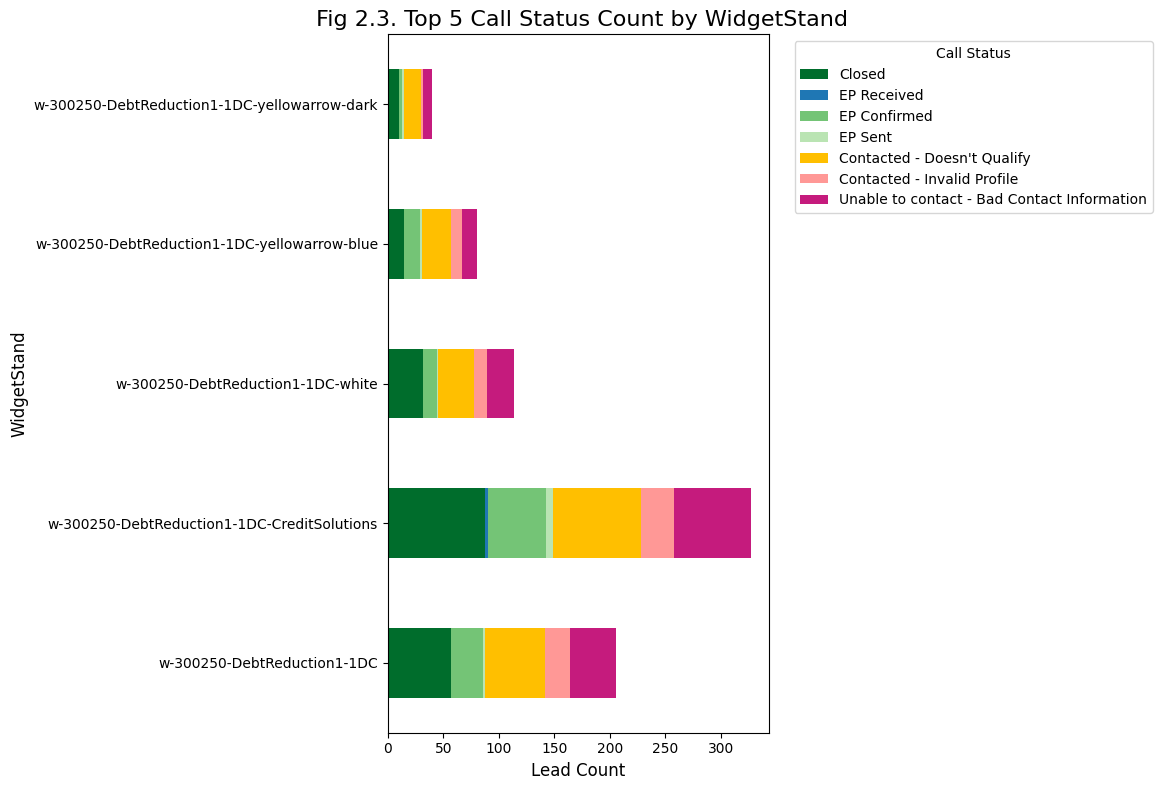

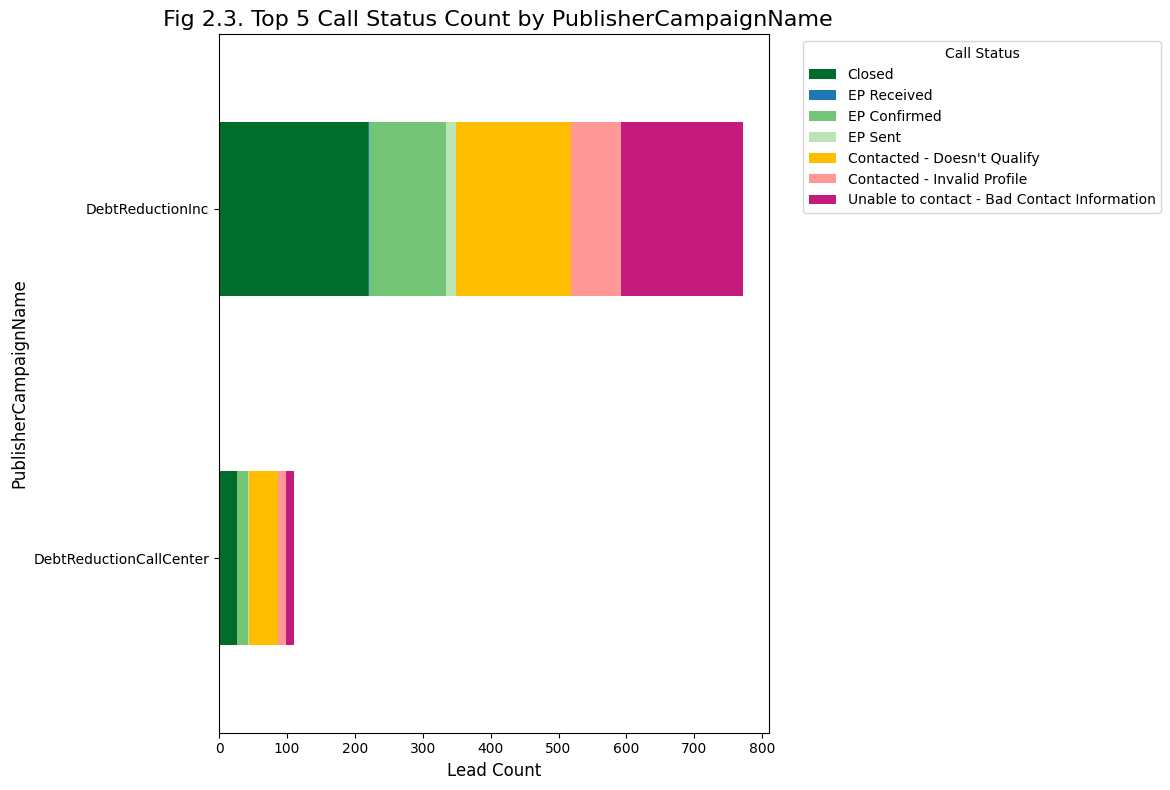

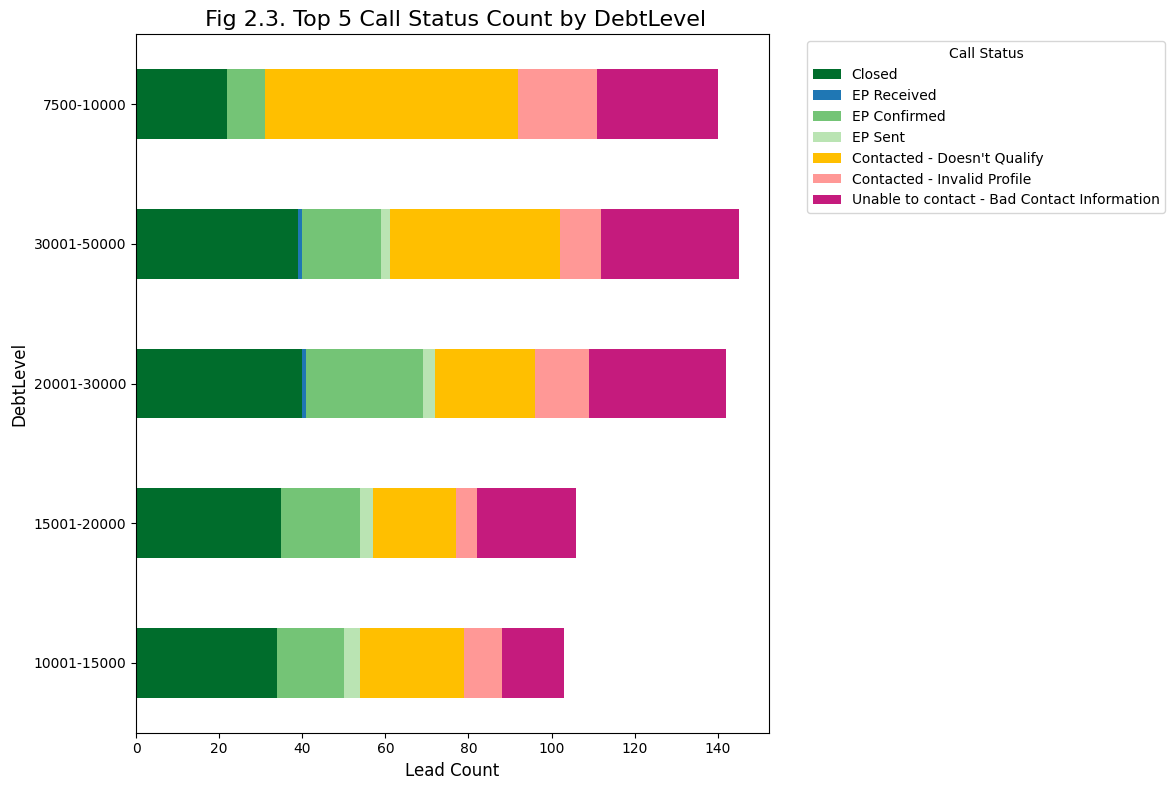

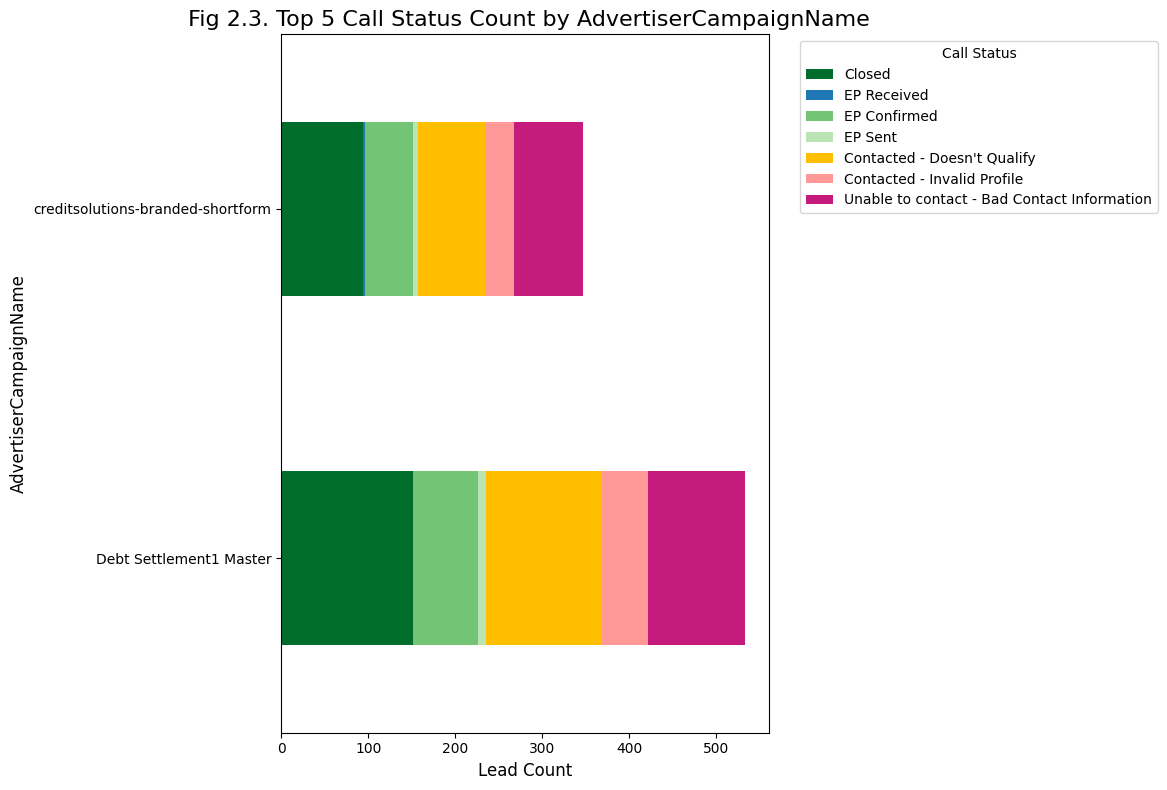

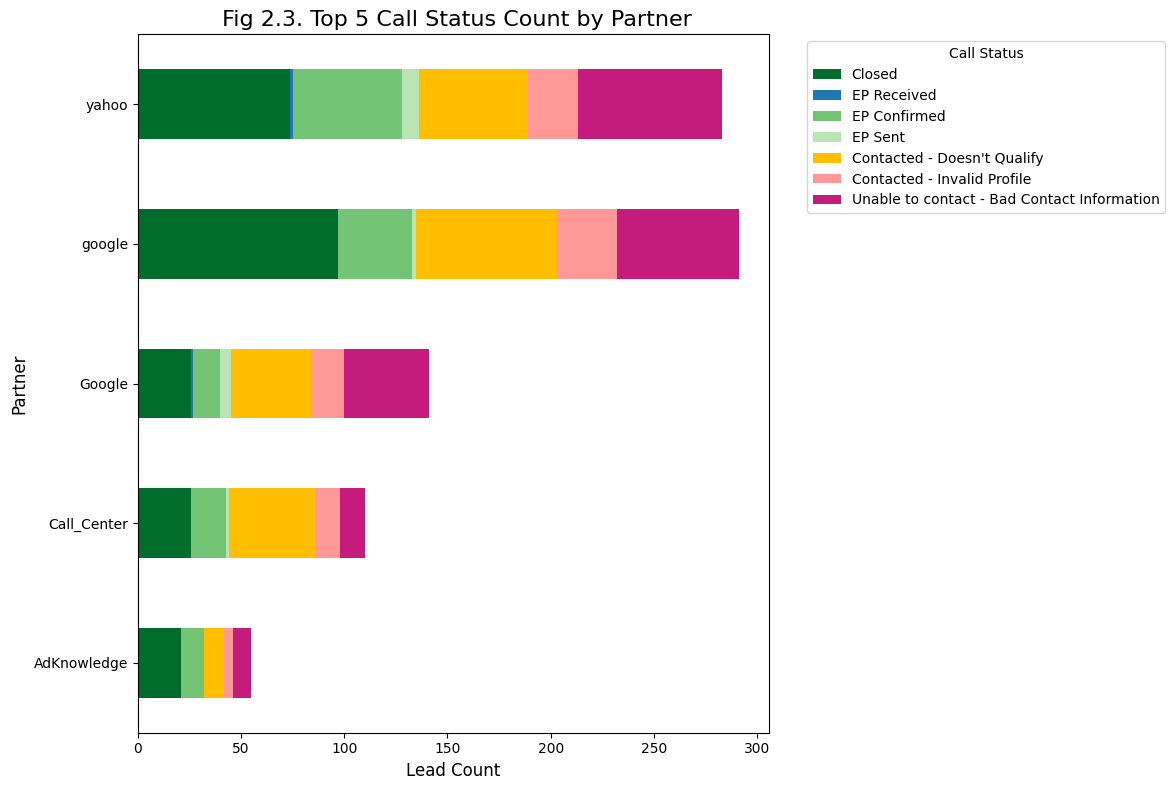

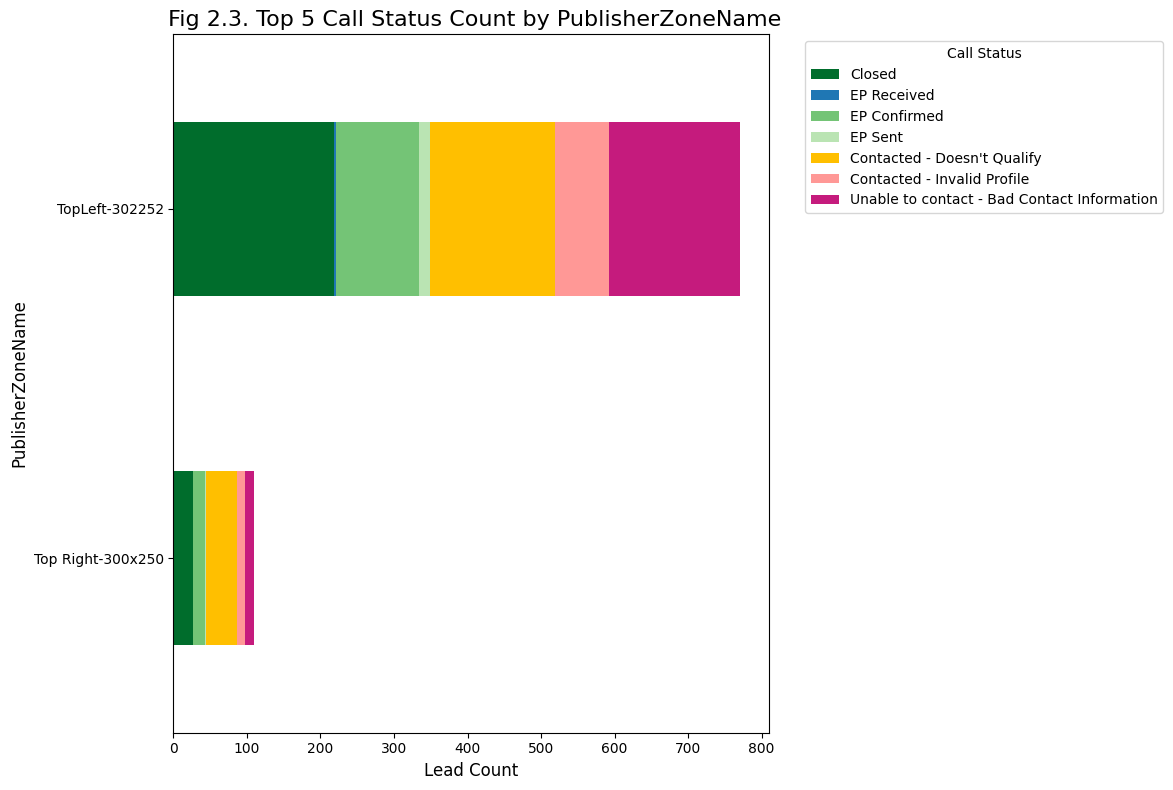

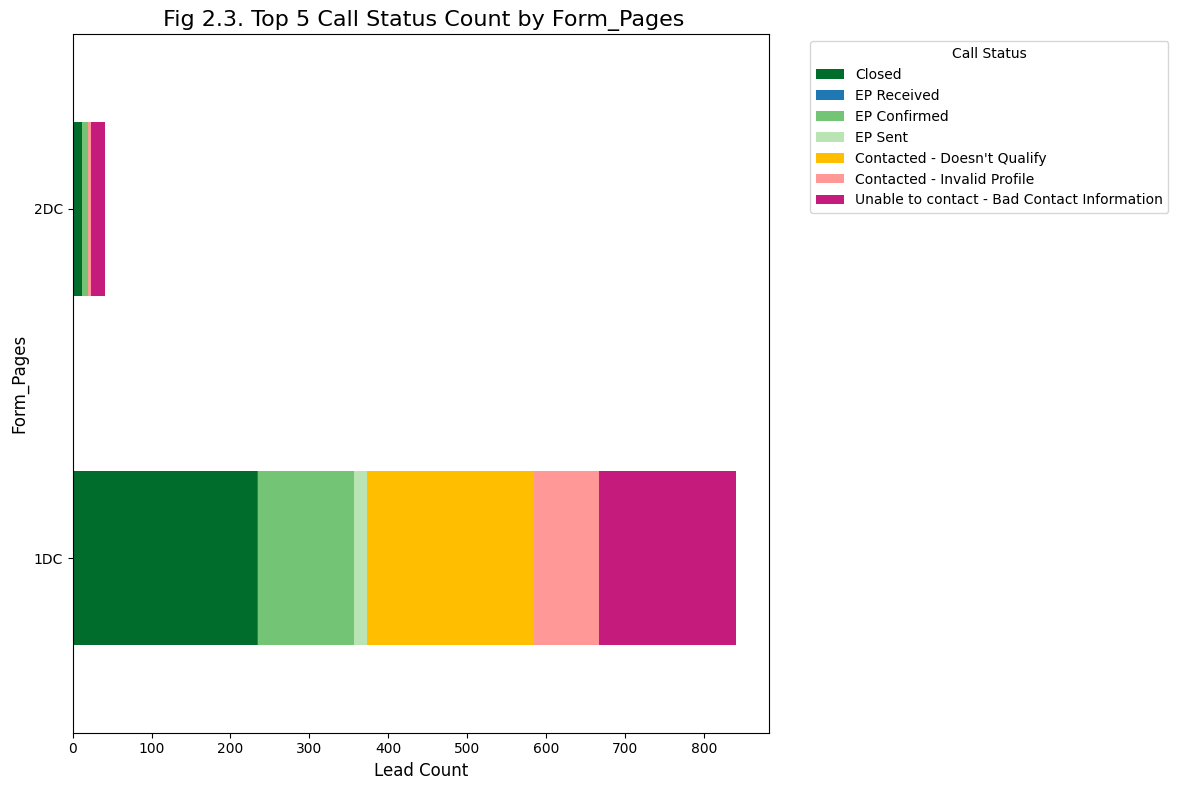

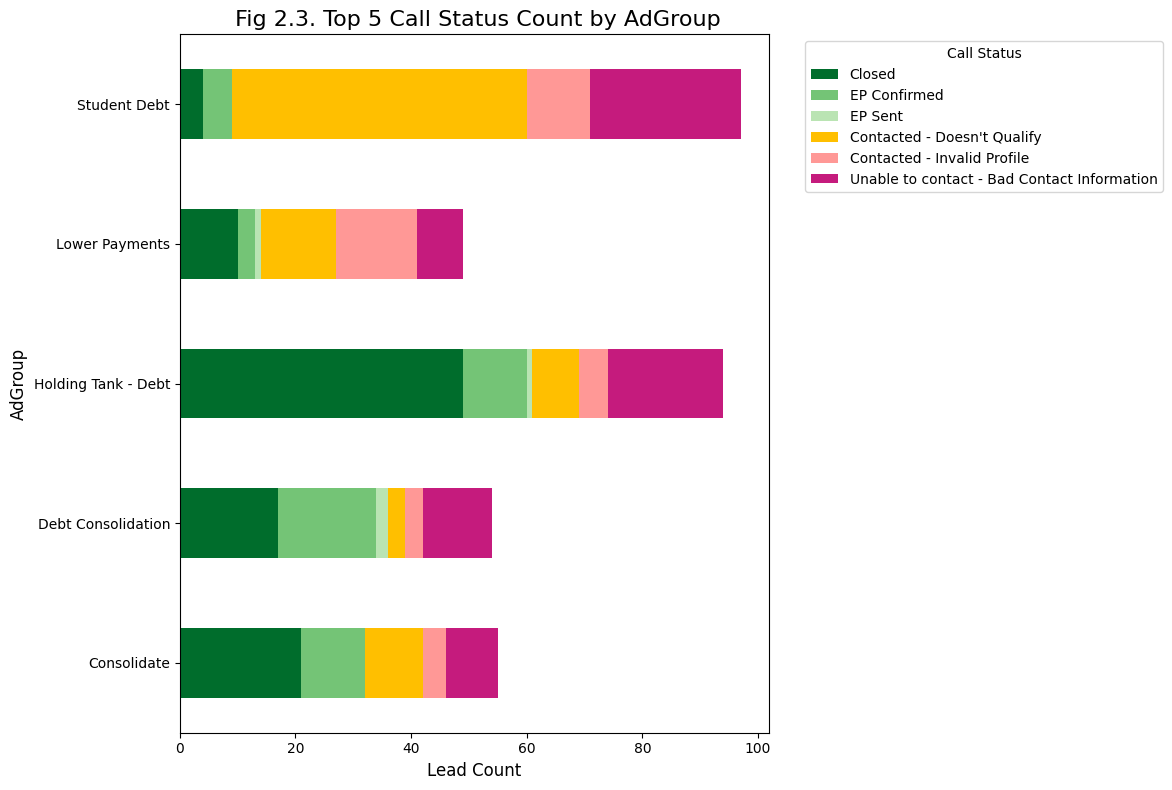

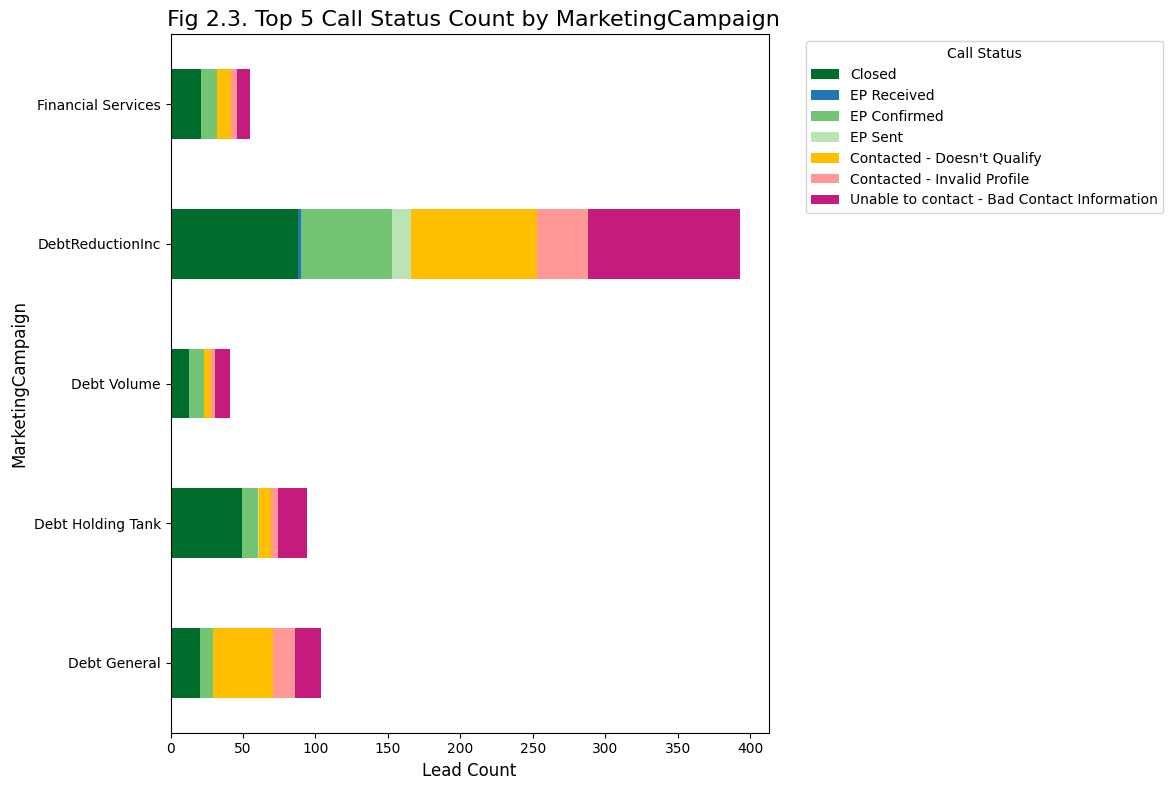

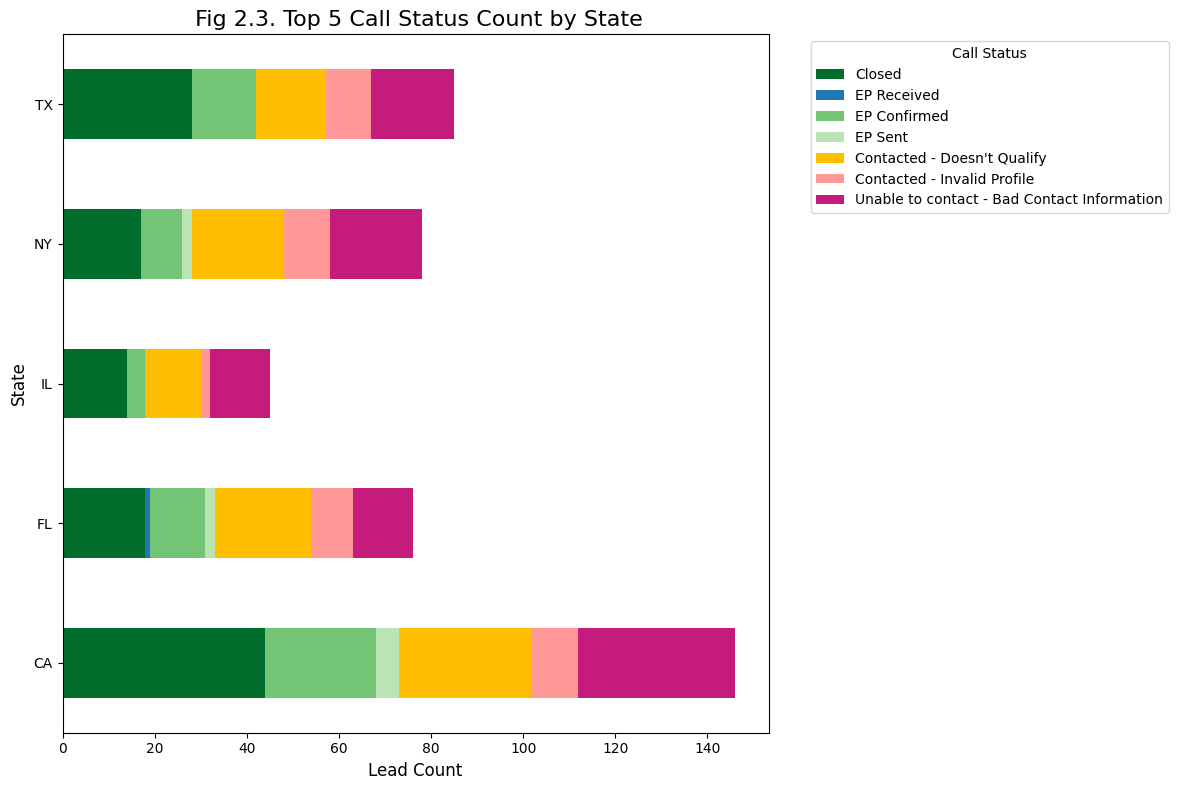

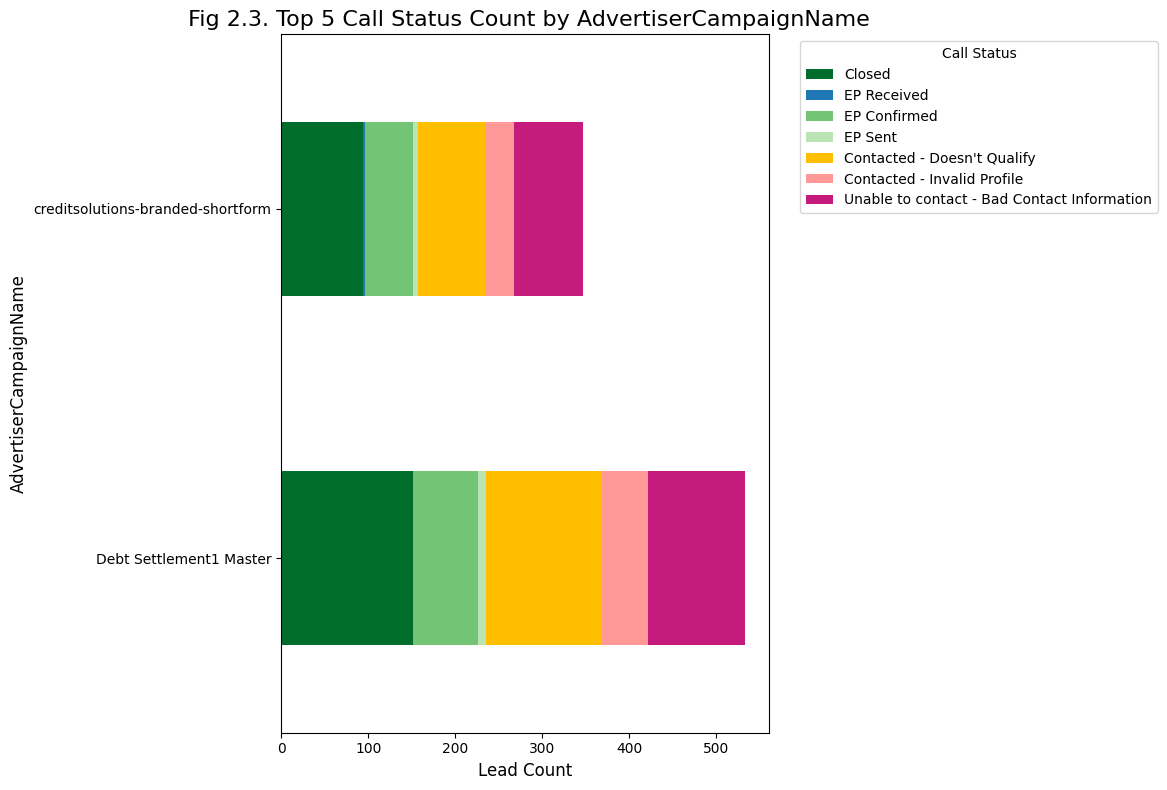

In [17]:
for cat in categories:

    top_values = df_clean[cat].value_counts().nlargest(5).index  #use df_clean for no NA data, use df for w/NA data
    df_filtered = df_clean[df_clean[cat].isin(top_values)]

    plot_data = df_filtered.groupby([cat, 'CallStatus']).size().unstack(fill_value=0)

    # Reorder columns
    existing_cols = [col for col in column_order1 if col in plot_data.columns]
    plot_data = plot_data[existing_cols]
    colors = [custom_colors1[col] for col in existing_cols]

    # Plot
    plt.figure(figsize=(12, 8))
    plot_data.plot(kind='barh', stacked=True, ax=plt.gca(), color=colors)

    plt.title(f' Fig 2.3.Top 5 Call Status Count by {cat}', fontsize=16)
    plt.xlabel('Lead Count', fontsize=12)
    plt.ylabel(cat, fontsize=12)
    plt.legend(title='Call Status', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [ ]:
#analyze more on the 7500-10000 bracket

dz_bracket = '7500-10000'
danger_zone = df_clean[df_clean['DebtLevel'] == dz_bracket]
others = df_clean[df_clean['DebtLevel'] != dz_bracket]

dq_rate_dz = (danger_zone['CallStatus'] == "Contacted - Doesn't Qualify").mean()
dq_rate_others = (others['CallStatus'] == "Contacted - Doesn't Qualify").mean()

closed_rate_dz = (danger_zone['CallStatus'] == "Closed").mean()
closed_rate_high_debt = (df_clean[df_clean['DebtLevel'] == '70001-90000']['CallStatus'] == "Closed").mean()

print(f"7.5k-10k Disqualification Rate: {dq_rate_dz:.1%}")
print(f"Overall Avg (Other Brackets) Disqualification Rate: {dq_rate_others:.1%}")
print(f"7.5k-10k Conversion (Closed) Rate: {closed_rate_dz:.1%}")
print(f"70k-90k Conversion (Closed) Rate: {closed_rate_high_debt:.1%}\n")


# comparing 1d vs 2d
dz_1dc_pct = (danger_zone['Form_Pages'] == '1DC').mean()
friction_dq_rate = df_clean.groupby('Form_Pages')['CallStatus'].apply(lambda x: (x == "Contacted - Doesn't Qualify").mean())


print(f"Percentage of 1DC usage in Danger Zone: {dz_1dc_pct:.1%}")
print(f"Disqualification Rate for 2DC Widgets: {friction_dq_rate.get('2DC', 0):.1%}\n")


# search display
g_comparison = df_clean[df_clean['Partner'].isin(['Google'])].groupby('Partner')['Is_Good'].mean()
y_comparison = df_clean[df_clean['Partner'].isin(['yahoo'])].groupby('Partner')['Is_Good'].mean()
specific_adgroups = ['Student Debt', 'Lower Payments']
low_intent_dz = danger_zone[danger_zone['AdGroup'].isin(specific_adgroups)]
good_lead_rate_low_intent = low_intent_dz['Is_Good'].mean()


print(f"Quality Rate for Google (Display): {g_comparison.get('Google', 0):.1%}")
print(f"Quality Rate for yahoo (Display): {g_comparison.get('yahoo', 0):.1%}")
print(f"Good Lead Rate for {specific_adgroups} in Danger Zone: {good_lead_rate_low_intent:.1%}\n")


# validation score
scores_dz = danger_zone[['PhoneScore', 'AddressScore']].mean()
scores_others = others[['PhoneScore', 'AddressScore']].mean()

print(f"Danger Zone - Avg Phone Score: {scores_dz['PhoneScore']:.2f} , Avg Address Score: {scores_dz['AddressScore']:.2f}")
print(f"Other Leads - Avg Phone Score: {scores_others['PhoneScore']:.2f} , Avg Address Score: {scores_others['AddressScore']:.2f}")

7.5k-10k Disqualification Rate: 43.6%
Overall Avg (Other Brackets) Disqualification Rate: 20.4%
7.5k-10k Conversion (Closed) Rate: 15.7%
70k-90k Conversion (Closed) Rate: 43.9%

Percentage of 1DC usage in Danger Zone: 100.0%
Disqualification Rate for 2DC Widgets: 0.0%

Quality Rate for Google (Display): 41.7%
Quality Rate for yahoo (Display): 0.0%
Good Lead Rate for ['Student Debt', 'Lower Payments'] in Danger Zone: 6.5%

Danger Zone - Avg Phone Score: 3.84 , Avg Address Score: 4.01
Other Leads - Avg Phone Score: 3.92 , Avg Address Score: 4.27


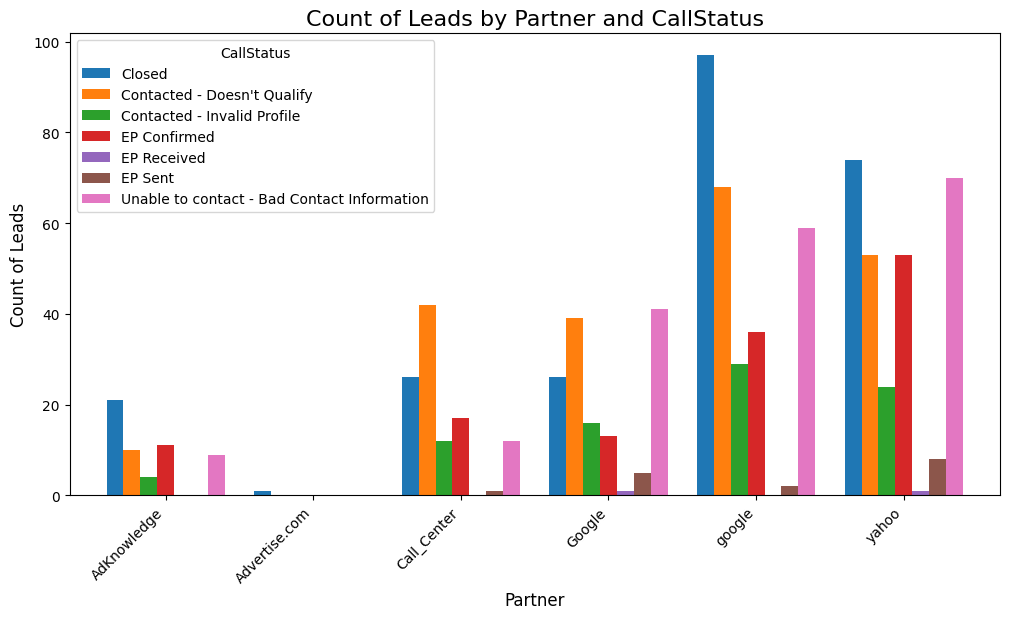

In [ ]:
debt_counts = df_clean.groupby(['Partner', 'CallStatus']).size().unstack(fill_value=0)

ax = debt_counts.plot(kind='bar', figsize=(12, 6), width=0.8)

plt.title('Count of Leads by Partner and CallStatus', fontsize=16)
plt.xlabel('Partner', fontsize=12)
plt.ylabel('Count of Leads', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

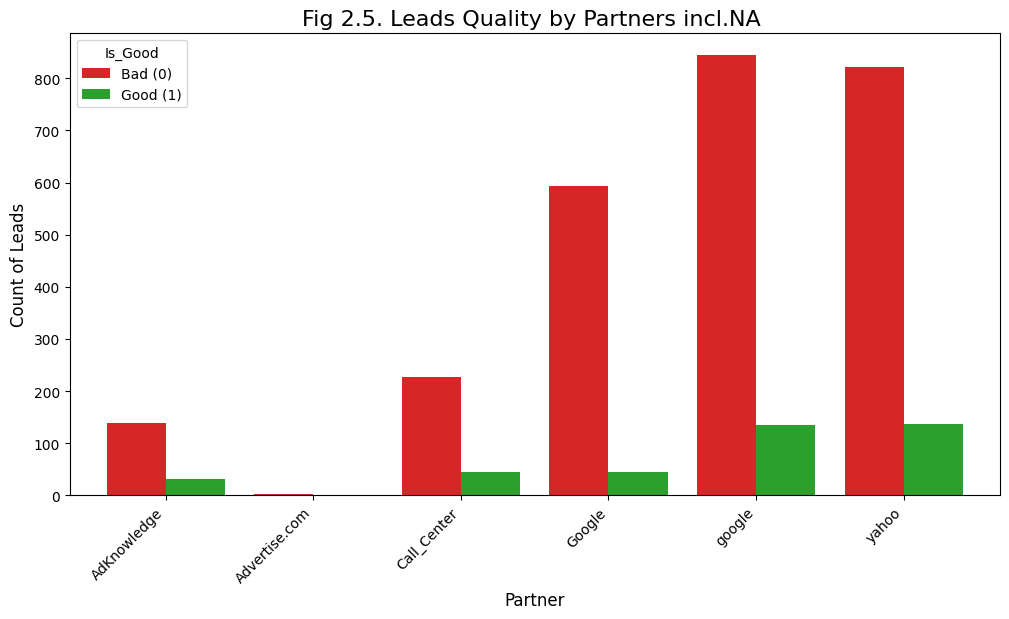

In [80]:


debt_counts = df.groupby(['Partner', 'Is_Good']).size().unstack(fill_value=0)
ax = debt_counts.plot(kind='bar', figsize=(12, 6), width=0.8, color=['#d62728', '#2ca02c'])

plt.title('Fig 2.5. Leads Quality by Partners incl.NA ', fontsize=16)
plt.xlabel('Partner', fontsize=12)
plt.ylabel('Count of Leads', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(['Bad (0)', 'Good (1)'], title='Is_Good')
plt.show()

In [ ]:
print(df[df["Partner"]=='Google']["SearchQuery"].unique())
print("-"*50)

df[df["Partner"]=='google']["SearchQuery"].unique()

[nan 'http://www.mydollarplan.com' 'http://getoutofdebt.org'
 'http://www.consolidate-studentloans.biz'
 'http://articles.everyquery.com' 'http://creditcards.j3hh.info'
 'direct student loan.gov' 'http://lopup.com'
 'http://www.discovertheinformation.com' 'GE Money Bank Online Services'
 'http://www.mycalculators.com' 'http://www.scribd.com'
 'http://www.kansan.com' 'http://studentloandebthelp.net'
 'http://www.complaintsboard.com']
--------------------------------------------------


array(['debt specialists', 'credit services', nan,
       'refinance loan debt consolidation lower interest',
       'how to solve federal default student loans',
       'american debt association', 'debt stoppers',
       'default student loan assistance',
       'student loan consolidation default',
       'college loan default money from gov',
       'www.creditcarddebthelp.com',
       'looking for old debts and how to fix them', 'debt law',
       'firstamericandebtrelief.com', 'debt free stimulus', 'rescue debt',
       'how to fix student loan default', 'creditcard debt',
       'best way to pay 61,000 in debt', 'chase.com/credit card payment',
       'student loan default help',
       'defaulted student loan consolidation', 'How to Fix Credit Myself',
       'abc debt relief', 'credit collectors',
       'chase.com creditcards payment', 'reviews debt settlement',
       'how to fix crediy',
       'best way to handle $250, 000 in credit card debts',
       'debt stimulus',
   

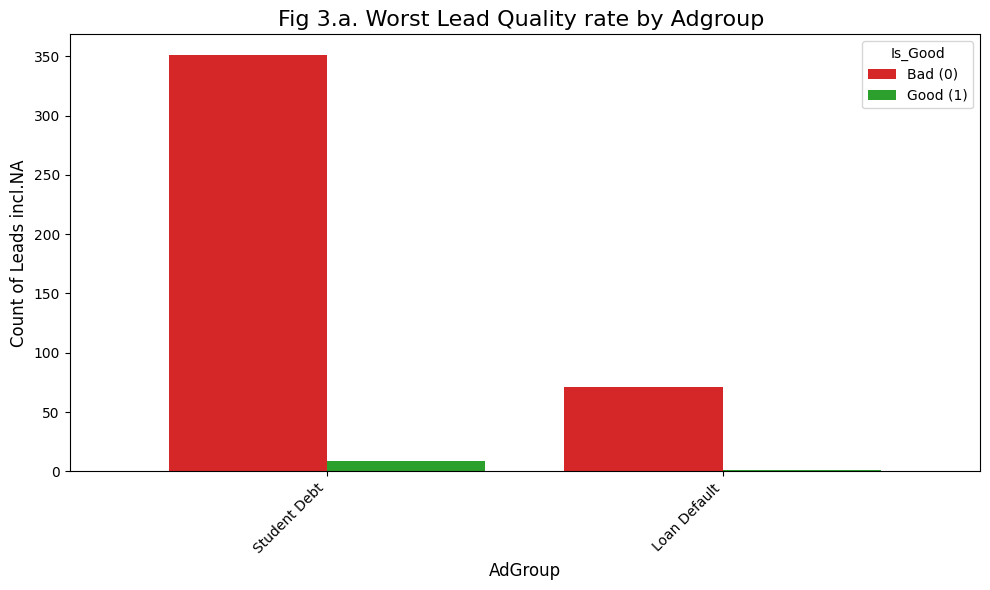

In [85]:
debt_counts = df.groupby(['AdGroup', 'Is_Good']).size().unstack(fill_value=0)

# Filter for specific AdGroups and plot
ax = debt_counts.loc[['Student Debt', 'Loan Default']].plot(kind='bar', figsize=(10, 6), width=0.8, color=['#d62728', '#2ca02c'])

plt.title('Fig 3.a. Worst Lead Quality rate by Adgroup ', fontsize=16)
plt.xlabel('AdGroup', fontsize=12)
plt.ylabel('Count of Leads incl.NA', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(['Bad (0)', 'Good (1)'], title='Is_Good')
plt.tight_layout()
plt.show()

In [25]:
debt_counts.sort_values("Bad Lead Percentage")

Is_Good,0.0,1.0,Total Leads,Bad Lead Percentage
AdGroup,,,,
Bankruptcy And Chapter 13,0,1,1,0.0
Bill Consolidation,0,2,2,0.0
Credit Card Debt (LV),0,1,1,0.0
Credit Card Debt Reduction,0,2,2,0.0
Debt Consolidate,0,1,1,0.0
...,...,...,...,...
How Settle,1,0,1,100.0
Credit Card Debt Consolidation Loan,1,0,1,100.0
Lower_Payments,1,0,1,100.0


In [87]:
# Form page (1DC/2DC) and Call Status analysis using Is_Good binary metric
partners_of_interest = ['Google', 'yahoo', 'google']
form_type = '1DC' #2DC

# filter for 1dc and partners
comparison_df = df_clean[(df_clean['Partner'].isin(partners_of_interest)) & (df_clean['Form_Pages'] == form_type)]

# Calc
metric_summary = comparison_df.groupby('Partner')['Is_Good'].apply(lambda x: pd.Series({
    'Good Quality Rate': x.mean(),
    'Bad Lead Rate ': 1 - x.mean(),
    'Total Lead Volume': len(x)
})).unstack()

print("---------------------", form_type, "-----------------")
metric_summary



--------------------- 1DC -----------------


,Good Quality Rate,Bad Lead Rate,Total Lead Volume
Partner,,,
Google,0.069579,0.930421,618.0
google,0.139102,0.860898,913.0
yahoo,0.145089,0.854911,896.0


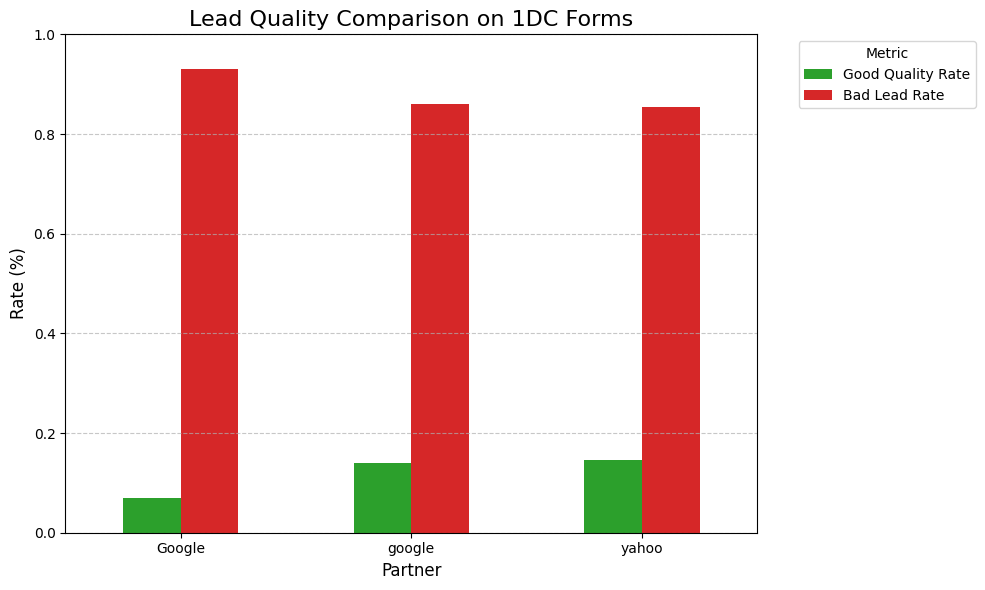

In [88]:
# Plotting the metric_summary
plot_data = metric_summary[['Good Quality Rate', 'Bad Lead Rate ']]
ax = plot_data.plot(kind='bar', figsize=(10, 6), color=['#2ca02c', '#d62728'])

plt.title(f'Lead Quality Comparison on {form_type} Forms', fontsize=16)
plt.ylabel('Rate (%)', fontsize=12)
plt.xlabel('Partner', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 4. Target % 9.6


<Figure size 1400x700 with 0 Axes>

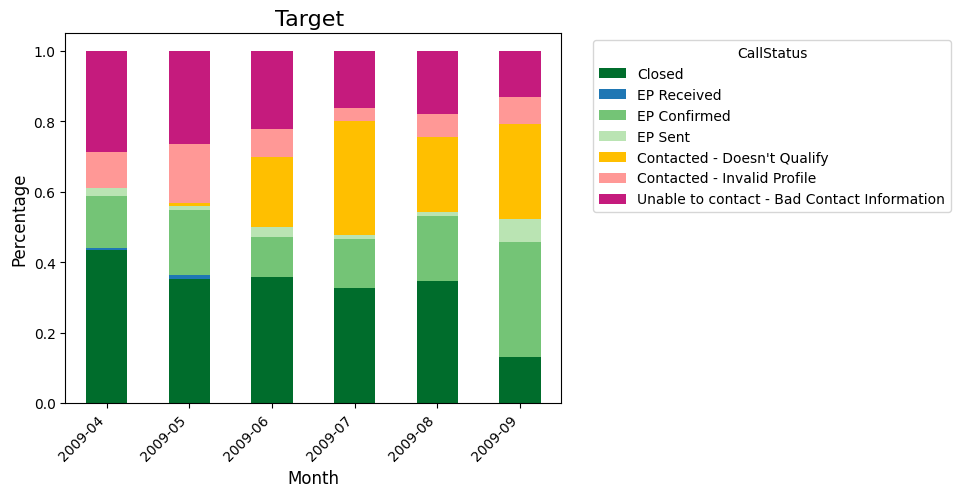

In [69]:
# gen new df
target_df = df[~df['AdGroup'].isin(['Student Debt'])]
target_df = target_df[~target_df['DebtLevel'].isin(['7500-10000'])]

callstatus_monthly_target = target_df.groupby(['Month', 'CallStatus']).size().unstack(fill_value=0)
callstatus_proportions_target = callstatus_monthly_target.div(callstatus_monthly_target.sum(axis=1), axis=0)
#reindex
callstatus_proportions_target = callstatus_proportions_target[orders]
#plot
plt.figure(figsize=(14, 7))
callstatus_proportions_target.plot(kind='bar', stacked=True, color=colors_to_use)

plt.title('Target ', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='CallStatus', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [91]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3021 entries, 0 to 3020
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   LeadCreated                  3021 non-null   datetime64[ns]
 1   FirstName                    3021 non-null   object        
 2   Email                        3021 non-null   object        
 3   VendorLeadID                 3013 non-null   object        
 4   CallStatus                   3021 non-null   object        
 5   WidgetName                   3021 non-null   object        
 6   PublisherZoneName            3021 non-null   object        
 7   PublisherCampaignName        3021 non-null   object        
 8   AddressScore                 1171 non-null   float64       
 9   PhoneScore                   1393 non-null   float64       
 10  AdvertiserCampaignName       3021 non-null   object        
 11  State                        3021 non-null 

In [96]:
widgetstand_quality = df_clean.groupby('WidgetStand')['Is_Good'].agg(['count', 'mean']).sort_values(by='mean', ascending=False)
widgetstand_quality.columns = ['Total Leads', 'Quality Rate']
print("Lead Quality by WidgetStand:")
display(widgetstand_quality)

Lead Quality by WidgetStand:


,Total Leads,Quality Rate
WidgetStand,,
w-300250-DebtReduction1-1DC-yellowarrow,49,0.244898
w-300250-DebtReduction1-1DC-Head2,89,0.157303
w-300250-DebtReduction1-1DC-BlueMeter,92,0.152174
w-300250-DebtReduction1-1DC,620,0.141935
w-300250-DebtReduction1-2DC-BlueMeter,87,0.137931
w-300250-DebtReduction1-1DC-yellowarrow-blue,232,0.133621
w-300250-DebtReduction1-1DC-CreditSolutions,1131,0.131742
w-300250-DebtReduction1-1DC-yellowarrow-dark,135,0.111111
w-300250-DebtReduction1-2DC-CreditSolutions,75,0.106667
